In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [164]:
df=pd.read_excel('EastWestAirlines.xlsx',sheet_name='data')

In [165]:
df.shape

(3999, 12)

In [166]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


### Data Preprocessing:

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [168]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [169]:
#checking duplicates
df.duplicated().sum()

0

In [170]:
# No duplicates are presented in data

In [171]:
#checking missing values
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

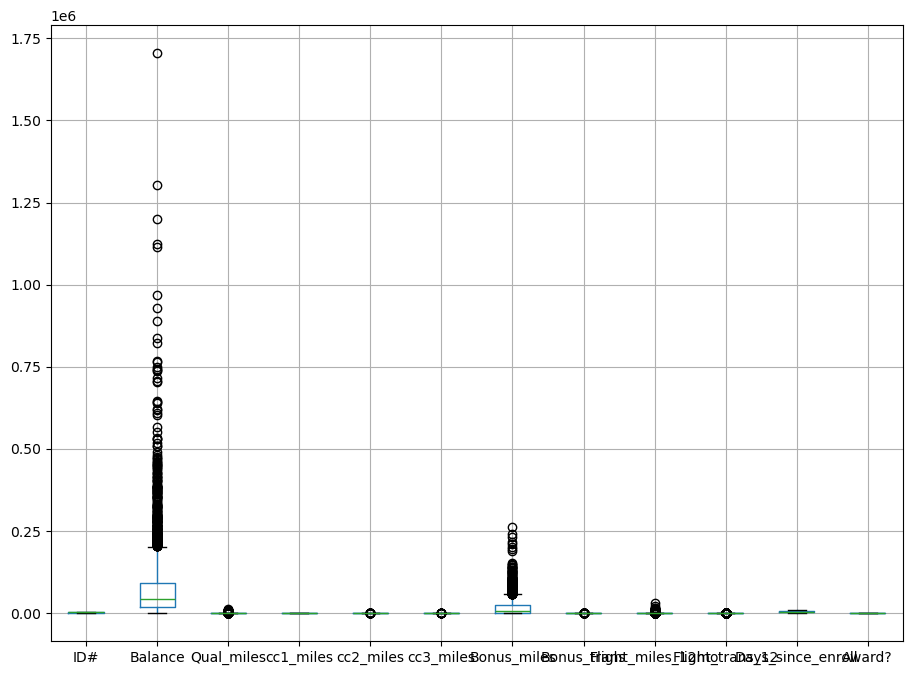

In [172]:
#checking outliers by using boxplot
plt.figure(figsize=(11,8))
df.boxplot()
plt.show()

In [173]:
#outlier capping 
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    high_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else high_extreme if x>high_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

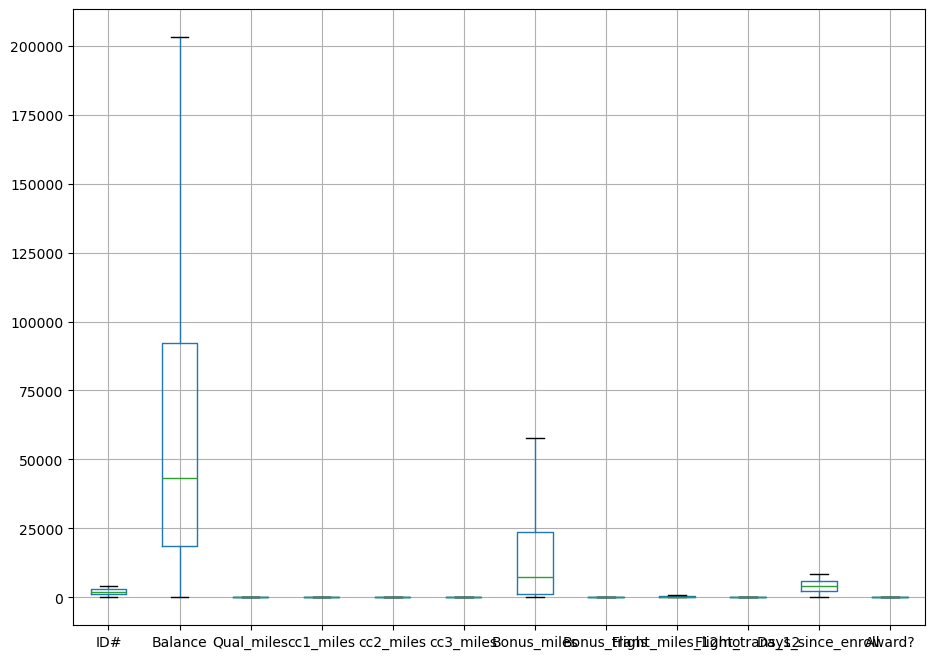

In [174]:
#checking outliers by using boxplot after outlier capping
plt.figure(figsize=(11,8))
df.boxplot()
plt.show()

In [175]:
df.drop(['ID#'], axis=1, inplace=True)

In [177]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled,columns=df.columns)
df_scaled.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918


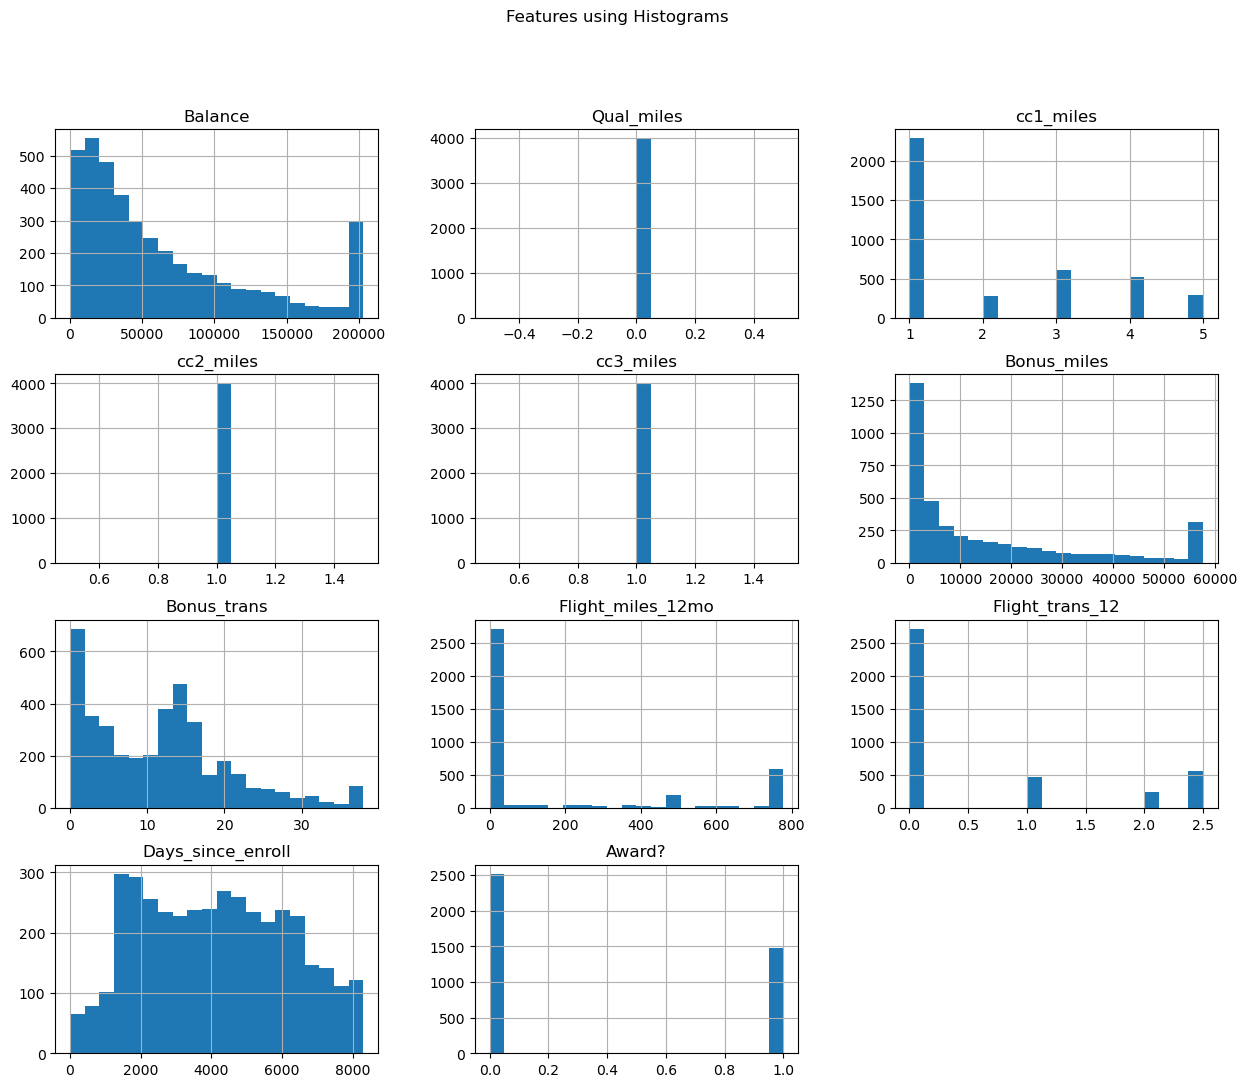

In [178]:
# histogram
df.hist(figsize=(15,12), bins=20)
plt.suptitle("Features using Histograms")
plt.show()

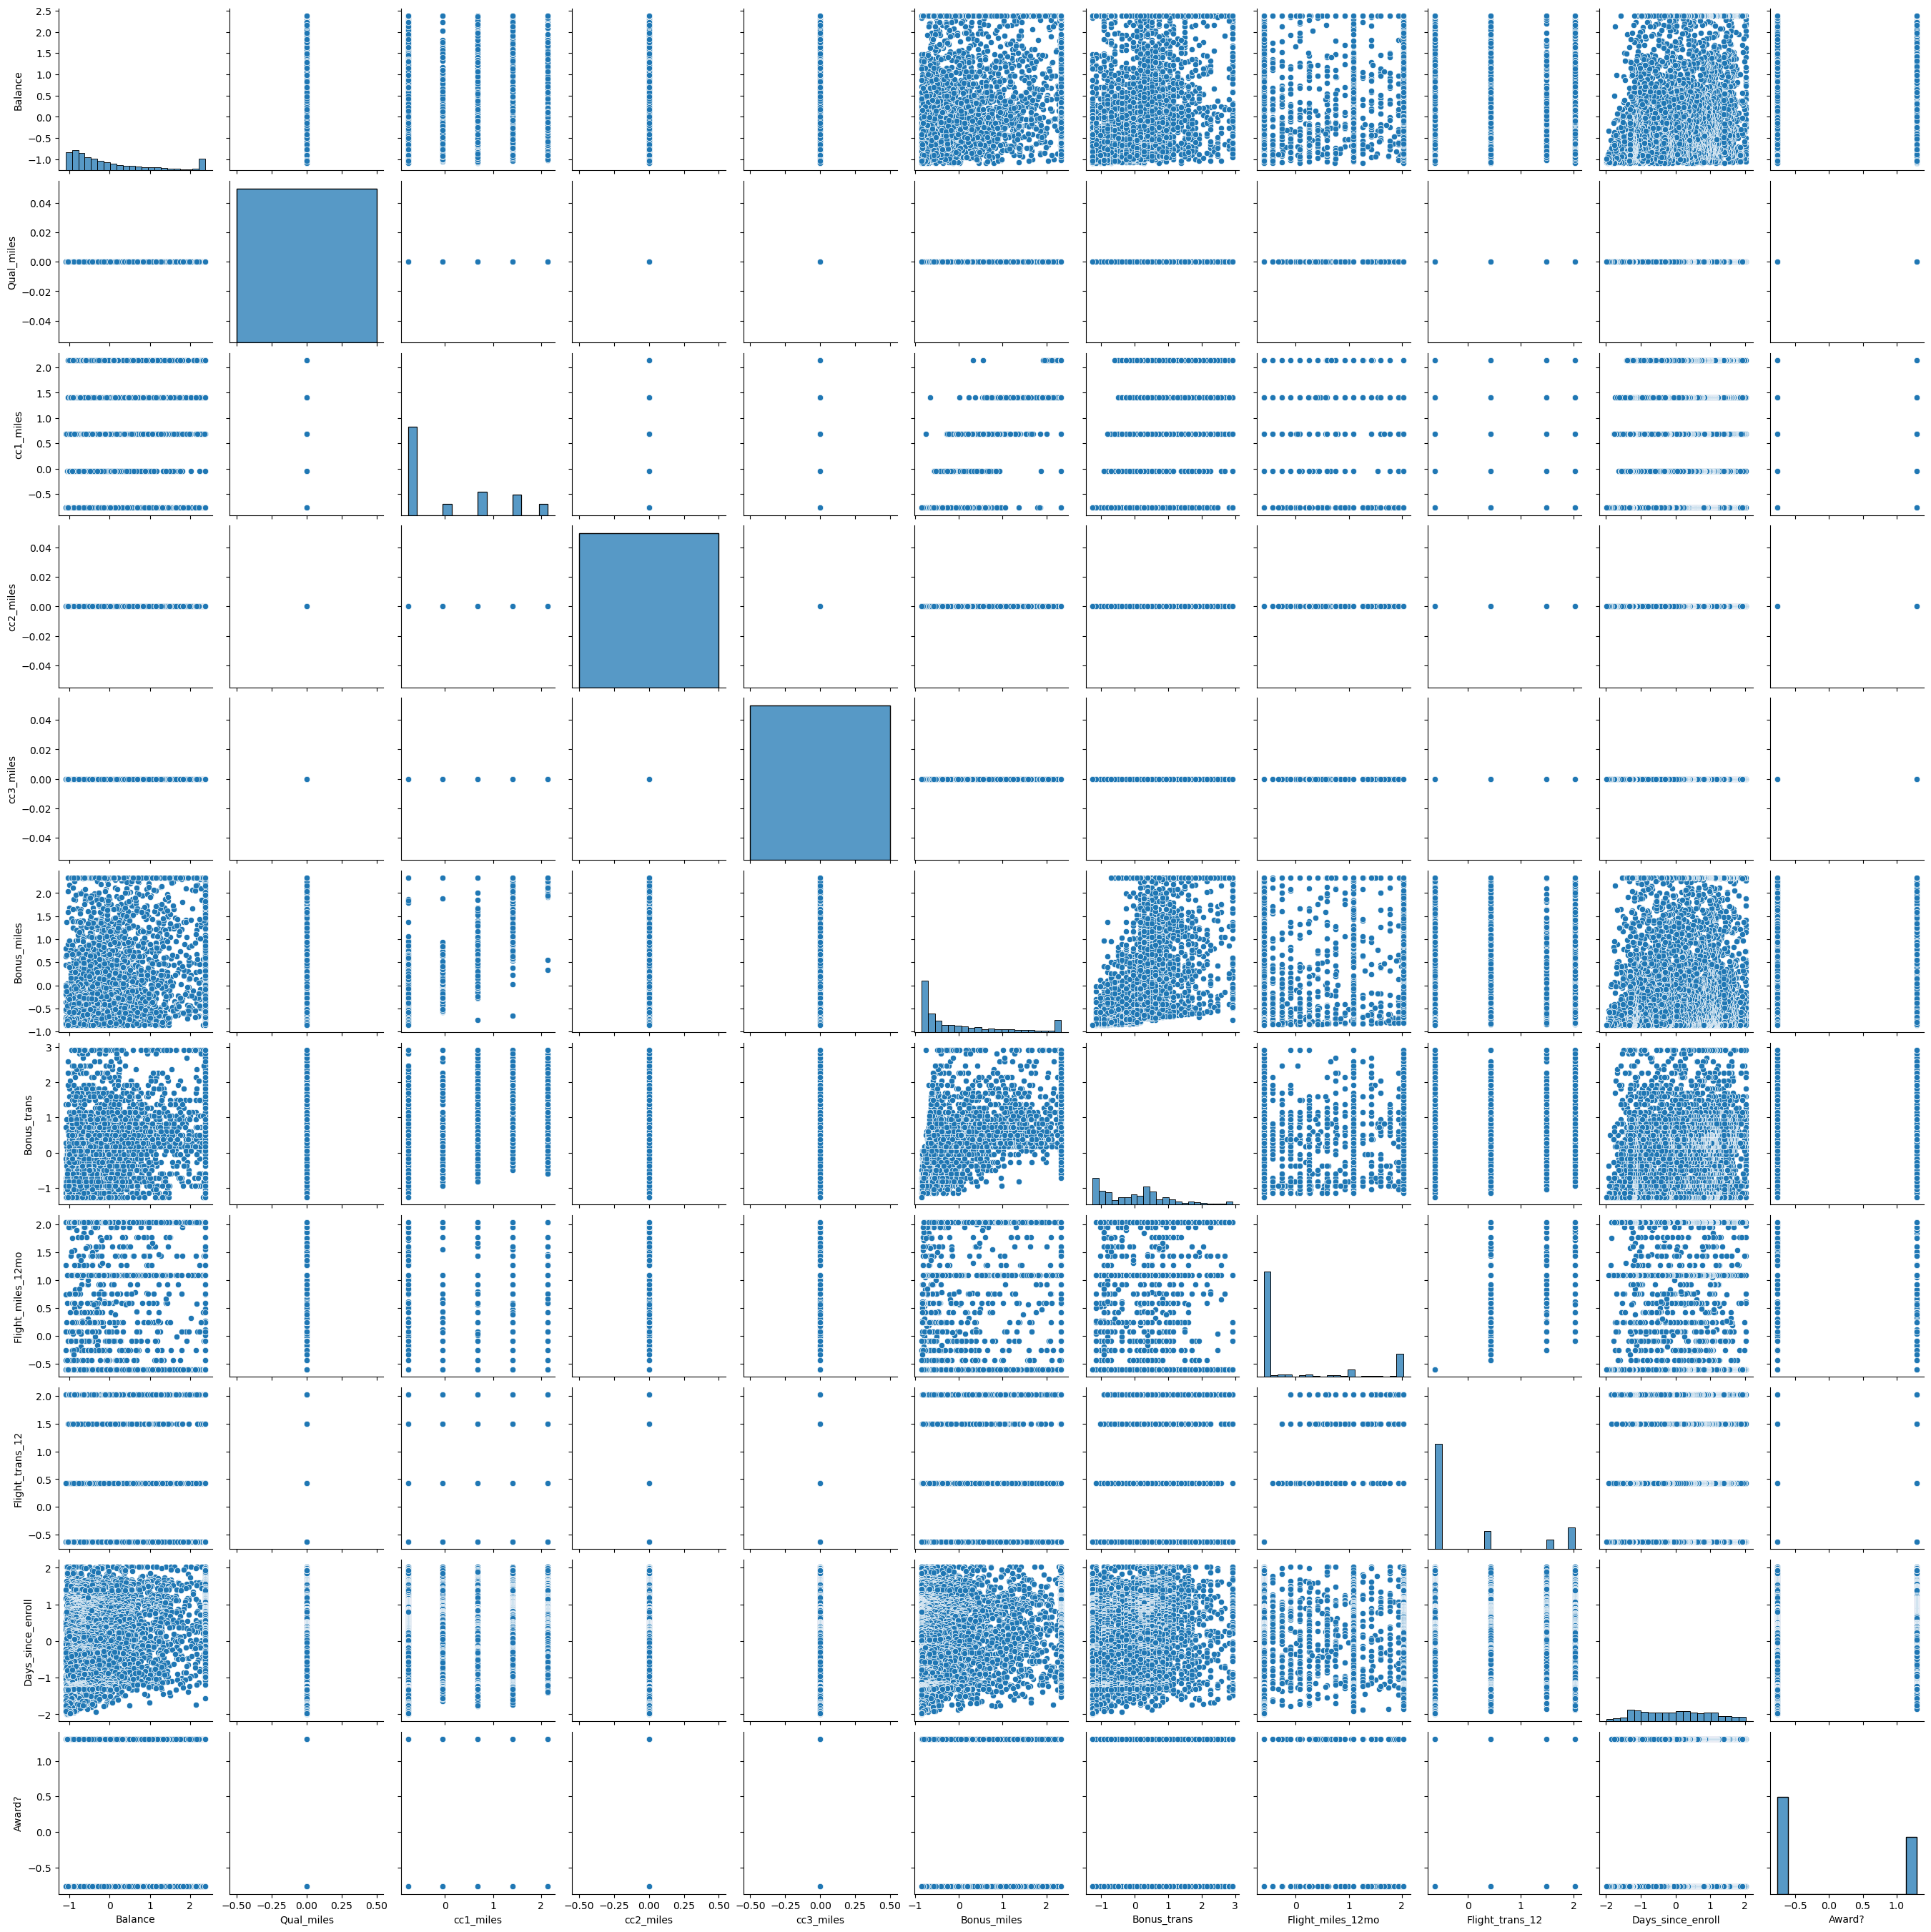

In [179]:
#Pair plot
sns.pairplot(df_scaled)
plt.show()

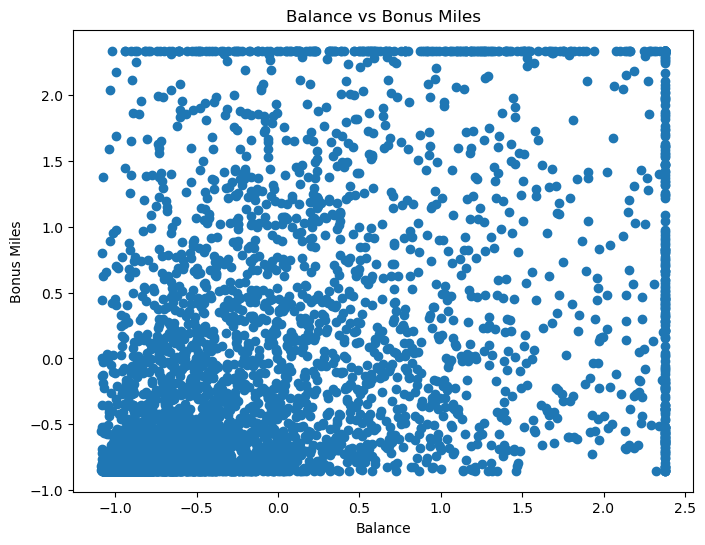

In [180]:
# scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df_scaled['Balance'],df_scaled['Bonus_miles'])
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("Balance vs Bonus Miles")
plt.show()

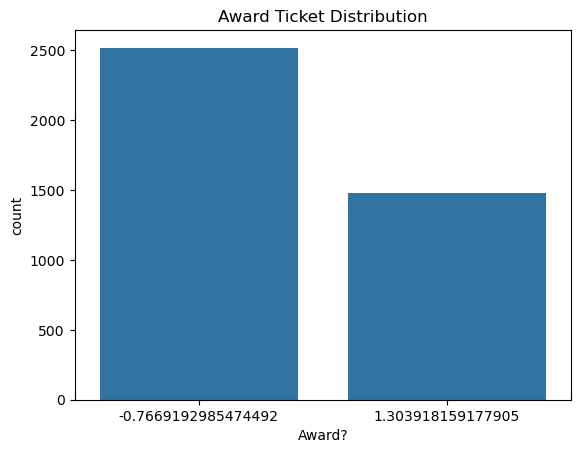

In [181]:
#count plot
sns.countplot(x='Award?', data=df_scaled)
plt.title("Award Ticket Distribution")
plt.show()

### Implementing Clustering Algorithms:

#### K-Means

In [188]:
from sklearn.cluster import KMeans

In [189]:
# Elbow method

In [190]:
inertia=[]
for i in range(1,10):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
print(inertia)

[31992.000000000004, 22258.866571262613, 17742.366953941655, 16022.645091290033, 13962.074948157024, 12446.953462676029, 11693.102263224202, 11057.78487017566, 10256.554227684945]


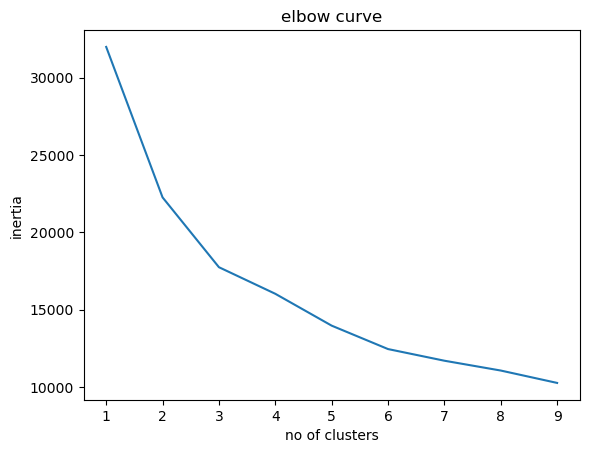

In [191]:
plt.plot(range(1,10),inertia)
plt.xlabel('no of clusters')
plt.ylabel('inertia')
plt.title('elbow curve')
plt.show()

In [192]:
kmeans_model = KMeans(n_clusters=4,random_state=42)
kmeans_clusters = kmeans_model.fit_predict(df_scaled)

In [193]:
kmeans_clusters

array([3, 3, 3, ..., 1, 3, 3])

In [194]:
# Add cluster labels to dataset
df_kmeans = df_scaled.copy()
df_kmeans['KMeans_Cluster'] = kmeans_clusters
df_kmeans.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919,3
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919,3
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919,3
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919,3
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918,2


#### DBSCAN

In [195]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [196]:
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

In [197]:
# Sort distances
distances = np.sort(distances[:,9])
distances

array([0.03452577, 0.03522026, 0.03555829, ..., 2.47813962, 2.57419463,
       2.62590521])

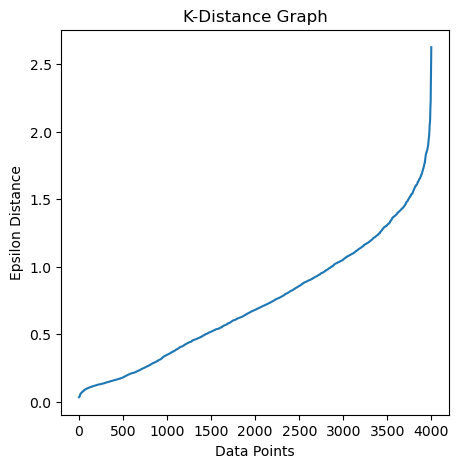

In [198]:
# Plot graph
plt.figure(figsize=(5,5))
plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Data Points")
plt.ylabel("Epsilon Distance")
plt.show()

In [199]:
# DBSCAN parameter tuning
eps=[0.5,0.8,1.0,1.2,1.5,2.0]
min_mode=range(2,15)
output=[]
for i in eps:
    for j in min_mode:
        labels=DBSCAN(eps=i,min_samples=j).fit(df_scaled).labels_
        if len(set(labels)) > 1:
            score=silhouette_score(df_scaled,labels)
            output.append([i,j,score])
print(output)

[[0.5, 2, -0.1884813169442352], [0.5, 3, -0.2025652795477887], [0.5, 4, -0.19110614827158887], [0.5, 5, -0.16625904358673524], [0.5, 6, -0.16908209196174], [0.5, 7, -0.17959509112761401], [0.5, 8, -0.2000291393449653], [0.5, 9, -0.19358131114905186], [0.5, 10, -0.21372559763549068], [0.5, 11, -0.21164669398811345], [0.5, 12, -0.14895771979046746], [0.5, 13, -0.09510497581722675], [0.5, 14, -0.13377712213309473], [0.8, 2, -0.18536227123257434], [0.8, 3, -0.1203624955135341], [0.8, 4, -0.1045484210729143], [0.8, 5, -0.10270926840590908], [0.8, 6, -0.11516655382180661], [0.8, 7, -0.11577534629440217], [0.8, 8, -0.10519026911628632], [0.8, 9, -0.059561083088103976], [0.8, 10, -0.10697665626761568], [0.8, 11, -0.041749559607097655], [0.8, 12, -0.024502896564182405], [0.8, 13, 0.0007502073711534752], [0.8, 14, -0.013172061881719122], [1.0, 2, -0.07605639145077796], [1.0, 3, -0.002992347464574999], [1.0, 4, 0.0019871175063671683], [1.0, 5, -0.008994802446905354], [1.0, 6, 0.006353392071718943

In [203]:
#best parameters
eps, min_samples, sil_score = sorted(output,reverse=True,key=lambda x:x[2])[0]
print('Best eps :', eps)
print('Best min_samples :', min_samples)
print('Best silhouette score :', sil_score)

Best eps : 1.2
Best min_samples : 14
Best silhouette score : 0.21599466823435243


In [204]:
dbscan = DBSCAN(eps=eps,min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(df_scaled)
print(dbscan_labels)

[0 0 0 ... 1 0 0]


In [205]:
# Add labels to dataframe
df_dbscan = df_scaled.copy()
df_dbscan['DBSCAN_Cluster'] =dbscan_labels
df_dbscan.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919,0
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919,0
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919,0
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919,0
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918,1


### Cluster Analysis and Interpretation:

In [206]:
# K-MEANS CLUSTER ANALYSIS
# Mean values of each cluster
kmeans_analysis = df_kmeans.groupby('KMeans_Cluster').mean()
kmeans_analysis

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,
0,0.210716,0.0,-0.615362,0.0,0.0,-0.428046,-0.105698,1.591311,1.588702,0.004452,0.297028
1,0.424917,0.0,1.013280,0.0,0.0,0.820236,0.578703,-0.515501,-0.505365,0.312483,0.304998
2,1.045038,0.0,1.427584,0.0,0.0,1.602210,1.476532,1.563470,1.510710,0.447013,0.895948
3,-0.529234,0.0,-0.675302,0.0,0.0,-0.663477,-0.604685,-0.553379,-0.547157,-0.272652,-0.457872


In [207]:
# K-MEANS CLUSTER SIZE
print(df_kmeans['KMeans_Cluster'].value_counts())

KMeans_Cluster
3    1903
1    1078
0     617
2     401
Name: count, dtype: int64


In [208]:
# DBSCAN CLUSTER ANALYSIS
dbscan_analysis = df_dbscan.groupby('DBSCAN_Cluster').mean()
dbscan_analysis

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
DBSCAN_Cluster,,,,,,,,,,,
-1,1.046065,0.0,0.697363,0.0,0.0,0.878500,1.155302,0.971552,1.056201,0.242900,0.460244
0,-0.233575,0.0,-0.336760,0.0,0.0,-0.387360,-0.365175,-0.327032,-0.332335,-0.177331,-0.766919
1,0.053200,0.0,0.384531,0.0,0.0,0.413321,0.265458,0.261678,0.239766,0.249684,1.303918


In [209]:
# DBSCAN CLUSTER SIZE
print(df_dbscan['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    2331
 1    1209
-1     459
Name: count, dtype: int64


#### K-Means Insights:


##### K-Means grouped customers based on travel and reward behavior.
##### Some clusters contain high-value frequent travelers.
##### Other clusters represent low activity customers.

#### DBSCAN Insights:


##### DBSCAN identified dense customer groups and noise points.
##### Customers labeled -1 are treated as outliers.
##### DBSCAN effectively detected irregular customer patterns.

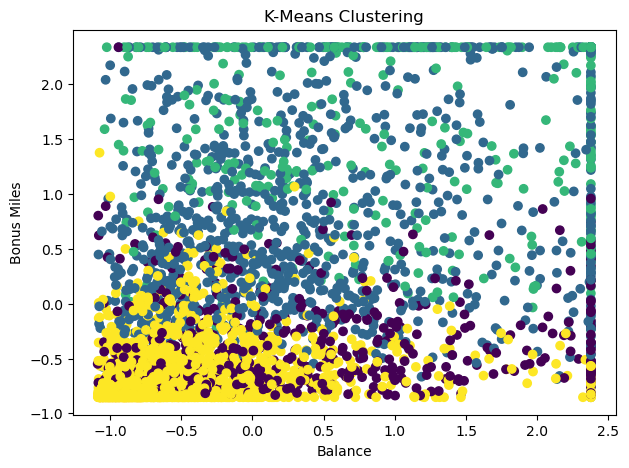

In [156]:
# K-MEANS CLUSTER VISUALIZATION
plt.figure(figsize=(7,5))
plt.scatter(df_scaled['Balance'],df_scaled['Bonus_miles'],c=kmeans_clusters,cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.show()

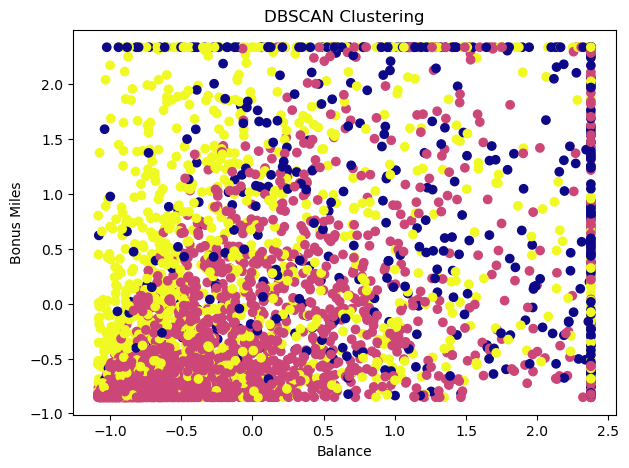

In [155]:
# DBSCAN CLUSTER VISUALIZATION
plt.figure(figsize=(7,5))
plt.scatter(df_scaled['Balance'],df_scaled['Bonus_miles'],c=dbscan_labels,cmap='plasma')
plt.title("DBSCAN Clustering")
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.show()

In [162]:
# K-MEANS SILHOUETTE SCORE
from sklearn.metrics import silhouette_score
kmeans_score = silhouette_score(df_scaled, kmeans_clusters)
print("K-Means Silhouette Score :", kmeans_score)

K-Means Silhouette Score : 0.307123045013532


In [160]:
# DBSCAN SILHOUETTE SCORE
dbscan_score = silhouette_score(df_scaled,dbscan_labels)
print("DBSCAN Silhouette Score :", dbscan_score)

DBSCAN Silhouette Score : 0.21599466823435243
